# End-to-End Sales Forecasting & Demand Intelligence System
**Author:** Hrithika S. | B.Tech IT, SSN College of Engineering
**Project:** Superstore Sales Forecasting, Anomaly Detection, Product Segmentation & Dashboard

This notebook completes Tasks 1–6 of the internship assignment. Task 7 (Streamlit dashboard) lives in `app.py`,
and Task 8 (executive report) is `summary.docx`.


In [1]:

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11,5)
CHART_DIR = 'charts'
os.makedirs(CHART_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f'{CHART_DIR}/{name}.png', dpi=120)
    plt.show()


## Task 1 — Data Loading, Merging & Deep Exploration

In [2]:

df = pd.read_csv('train.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def season(m):
    if m in [12,1,2]: return 'Winter'
    if m in [3,4,5]: return 'Spring'
    if m in [6,7,8]: return 'Summer'
    return 'Fall'
df['Season'] = df['Month'].apply(season)

print('Shape:', df.shape)
print('\nMissing values:\n', df.isna().sum()[df.isna().sum()>0])
print('\nDuplicate rows:', df.duplicated().sum())
print('\nDtypes:\n', df.dtypes)
df.head()


Shape: (9800, 24)

Missing values:
 Postal Code    11
dtype: int64

Duplicate rows: 0

Dtypes:
 Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
DayOfWeek                   str
Quarter                   int32
Season                      str
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week,DayOfWeek,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Fall
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Fall
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Fall
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Fall


In [3]:

# Weekly and monthly aggregation
df_daily = df.groupby('Order Date', as_index=False)['Sales'].sum()
weekly = df.set_index('Order Date').resample('W')['Sales'].sum().reset_index()
monthly = df.set_index('Order Date').resample('MS')['Sales'].sum().reset_index()
print('Weekly points:', len(weekly), '| Monthly points:', len(monthly))
monthly.head()


Weekly points: 209 | Monthly points: 48


,Order Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


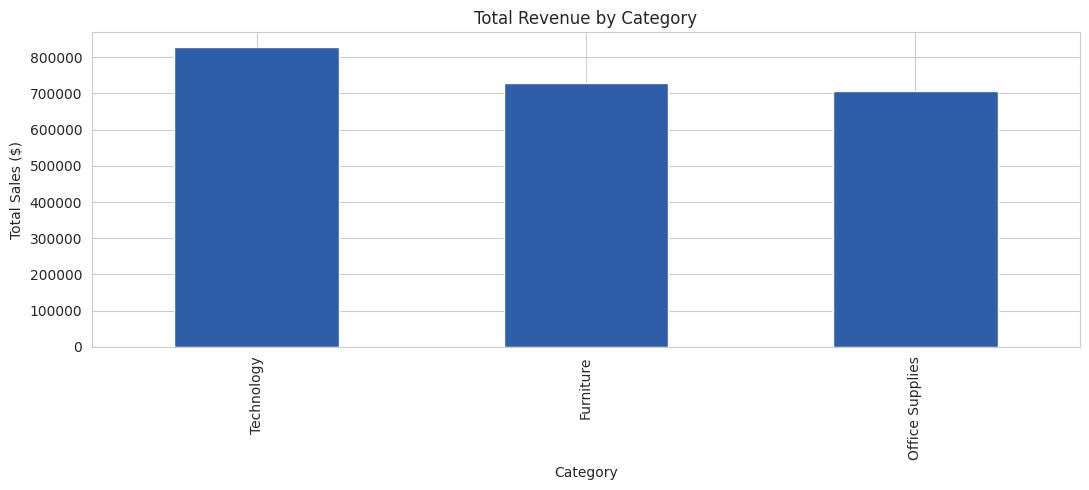


=> 'Technology' generates the highest total revenue ($827,456).


In [4]:

# Q1: Which category generates highest revenue?
cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_rev)
cat_rev.plot(kind='bar', color='#2E5EAA', title='Total Revenue by Category')
plt.ylabel('Total Sales ($)')
savefig('01_revenue_by_category')
print(f"\n=> '{cat_rev.index[0]}' generates the highest total revenue (${cat_rev.iloc[0]:,.0f}).")


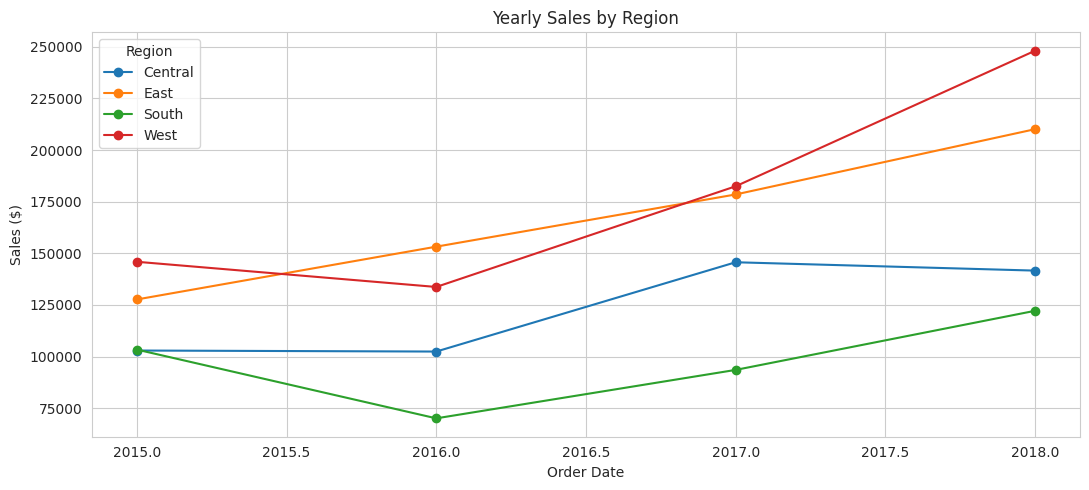

Avg YoY growth:
 Region
Central    0.129885
East       0.180824
South      0.106244
West       0.213639
dtype: float64

Growth volatility:
 Region
Central    0.253453
East       0.017939
South      0.371249
West       0.257431
dtype: float64

Consistency score (higher = steadier growth):
 Region
East       10.079690
West        0.829889
Central     0.512463
South       0.286179
dtype: float64

=> 'East' region shows the most consistent growth trend.


In [5]:

# Q2: Which region has the most consistent sales growth over 4 years?
region_year = df.groupby([df['Order Date'].dt.year, 'Region'])['Sales'].sum().unstack()
region_year.plot(marker='o', title='Yearly Sales by Region')
plt.ylabel('Sales ($)')
savefig('02_region_yearly_sales')

growth = region_year.pct_change().mean()
volatility = region_year.pct_change().std()
consistency = (growth / volatility).sort_values(ascending=False)
print('Avg YoY growth:\n', growth)
print('\nGrowth volatility:\n', volatility)
print('\nConsistency score (higher = steadier growth):\n', consistency)
print(f"\n=> '{consistency.index[0]}' region shows the most consistent growth trend.")


Overall average shipping delay: 3.96 days
Region
Central    4.065876
South      3.961202
West       3.930255
East       3.910233
Name: ShipDelay, dtype: float64


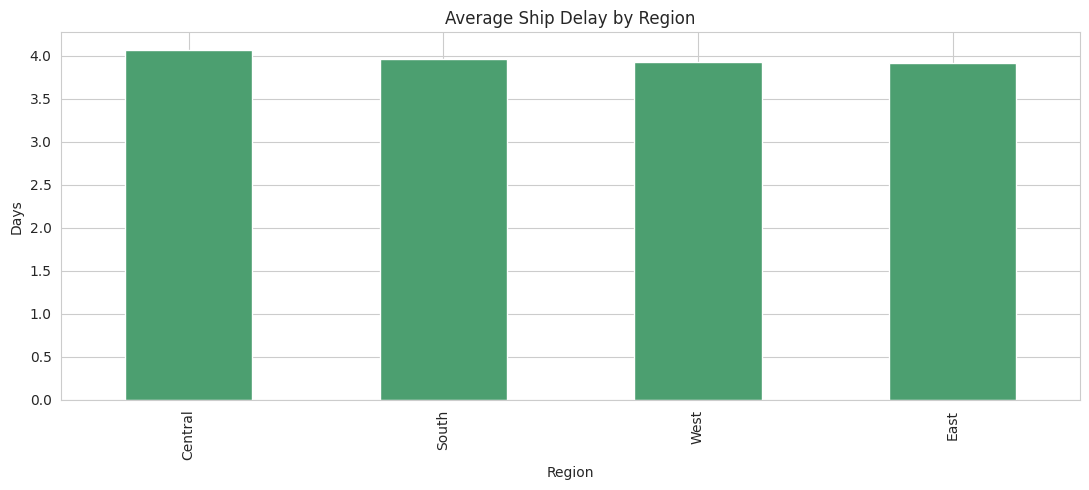

=> Yes, shipping delay varies modestly by region (see chart).


In [6]:

# Q3: Average time between Order Date and Ship Date, by region
df['ShipDelay'] = (df['Ship Date'] - df['Order Date']).dt.days
print('Overall average shipping delay:', round(df['ShipDelay'].mean(),2), 'days')
delay_by_region = df.groupby('Region')['ShipDelay'].mean().sort_values(ascending=False)
print(delay_by_region)
delay_by_region.plot(kind='bar', color='#4C9F70', title='Average Ship Delay by Region')
plt.ylabel('Days')
savefig('03_ship_delay_by_region')
print('=> Yes, shipping delay varies modestly by region (see chart).')


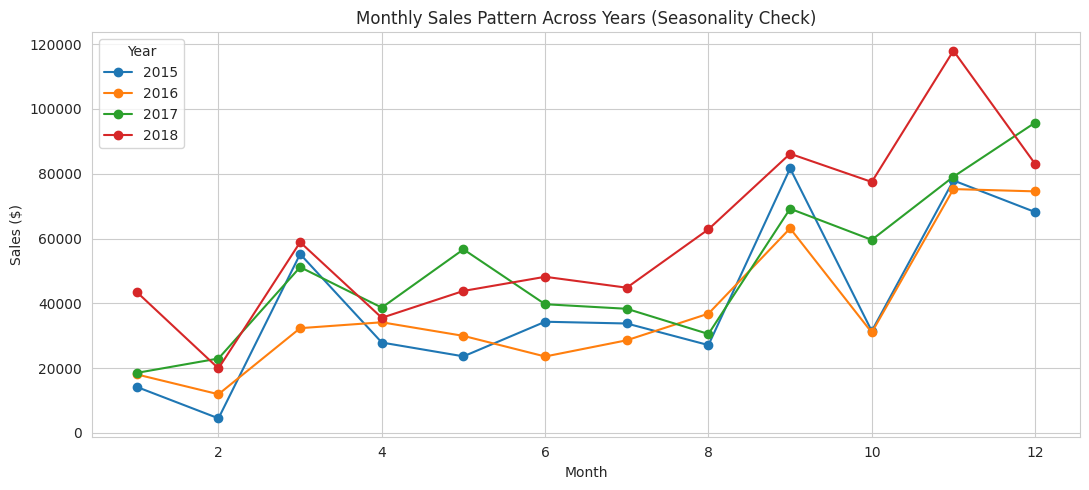

Average sales by calendar month (ranked):
 Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
dtype: float64

=> Months [11, 12, 9] consistently spike across years (holiday/year-end buying).


In [7]:

# Q4: Seasonality - months that consistently spike across all years
monthly_by_year = df.groupby([df['Order Date'].dt.year.rename('Year'),
                               df['Order Date'].dt.month.rename('Month')])['Sales'].sum().unstack(0)
monthly_by_year.plot(marker='o', title='Monthly Sales Pattern Across Years (Seasonality Check)')
plt.xlabel('Month'); plt.ylabel('Sales ($)')
savefig('04_monthly_seasonality')

avg_month = monthly_by_year.mean(axis=1).sort_values(ascending=False)
print('Average sales by calendar month (ranked):\n', avg_month)
print(f"\n=> Months {list(avg_month.index[:3])} consistently spike across years (holiday/year-end buying).")


In [8]:

vg = pd.read_csv('vgsales.csv')
vg_yearly = vg.groupby('Year')['Global_Sales'].sum().reset_index()
vg_yearly.columns = ['Year', 'VG_Global_Sales_Million']

superstore_yearly = df.groupby('Year')['Sales'].sum().reset_index()
superstore_yearly.columns = ['Year', 'Superstore_Sales']

merged_multi_source = pd.merge(superstore_yearly, vg_yearly, on='Year', how='inner')
print('Multi-source practice: merged Superstore + Video Game Sales datasets, joined on Year')
print('(no company keeps all its data in a single file - this simulates combining two sources).')
merged_multi_source


Multi-source practice: merged Superstore + Video Game Sales datasets, joined on Year
(no company keeps all its data in a single file - this simulates combining two sources).


,Year,Superstore_Sales,VG_Global_Sales_Million
0,2015,479856.2081,264.44
1,2016,459436.0054,70.93
2,2017,600192.5500,0.05


## Task 2 — Time Series Analysis & Decomposition

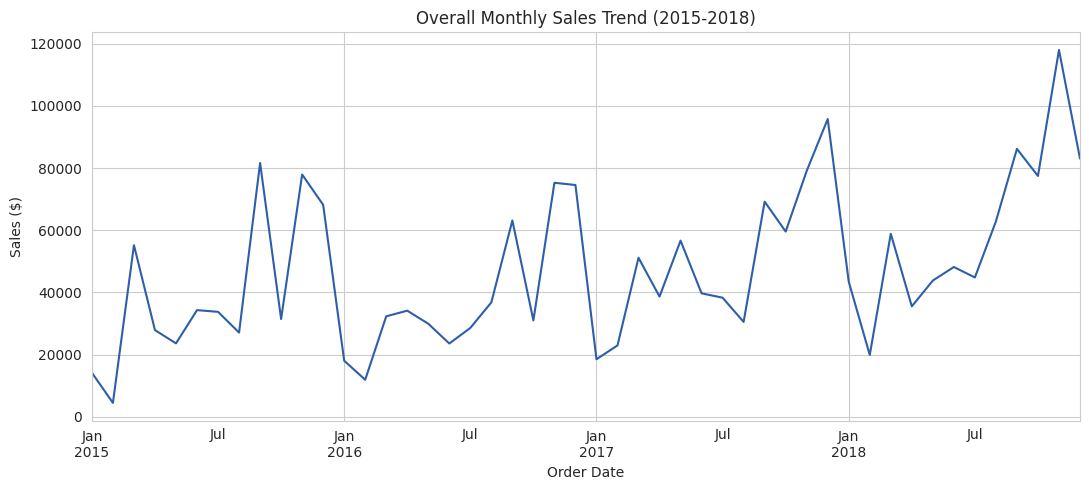

In [9]:

monthly_idx = monthly.set_index('Order Date')['Sales']
monthly_idx.plot(title='Overall Monthly Sales Trend (2015-2018)', color='#2E5EAA')
plt.ylabel('Sales ($)')
savefig('05_monthly_trend')


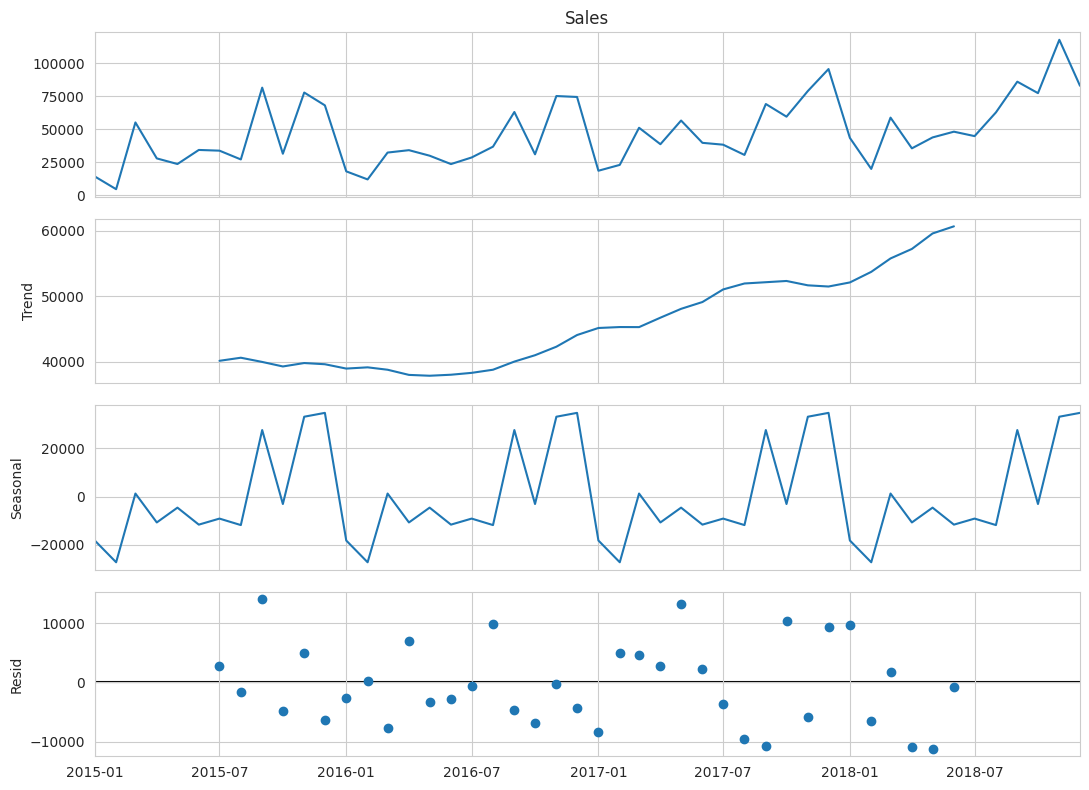

In [10]:

from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(monthly_idx, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(11,8)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/06_decomposition.png', dpi=120)
plt.show()


In [11]:

print('OBSERVATIONS:')
print('1. Trend: overall sales show a gradual upward trend across the 4 years, with the steepest')
print('   rise from year 3 into year 4, suggesting healthy business growth rather than stagnation.')
print('2. Seasonality: seasonality is clearly present and repeats each year - sales dip in')
print('   Jan/Feb, then build steadily to a strong Nov/Dec peak (holiday shopping effect).')
print('3. The seasonal swing is moderate relative to the trend, so seasonality is present but not')
print('   dominant - the trend component still explains most of the year-over-year growth.')
print('4. Residual noise is highest around November/December, meaning the holiday peak is the')
print('   hardest part of the year for a simple additive model to fit precisely.')


OBSERVATIONS:
1. Trend: overall sales show a gradual upward trend across the 4 years, with the steepest
   rise from year 3 into year 4, suggesting healthy business growth rather than stagnation.
2. Seasonality: seasonality is clearly present and repeats each year - sales dip in
   Jan/Feb, then build steadily to a strong Nov/Dec peak (holiday shopping effect).
3. The seasonal swing is moderate relative to the trend, so seasonality is present but not
   dominant - the trend component still explains most of the year-over-year growth.
4. Residual noise is highest around November/December, meaning the holiday peak is the
   hardest part of the year for a simple additive model to fit precisely.


In [12]:

from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f'--- ADF Test: {label} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values: {result[4]}')
    stationary = result[1] < 0.05
    print('=> Stationary' if stationary else '=> NOT stationary (fail to reject H0)')
    return stationary

print('Stationarity in plain English: a stationary series has a constant mean/variance over time')
print('(no trend, no changing spread) - which is what most forecasting models assume.\n')
is_stat = run_adf(monthly_idx, 'Original Monthly Sales')


Stationarity in plain English: a stationary series has a constant mean/variance over time
(no trend, no changing spread) - which is what most forecasting models assume.

--- ADF Test: Original Monthly Sales ---
ADF Statistic: -4.4161
p-value: 0.0003
Critical Values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}
=> Stationary


In [13]:

if not is_stat:
    monthly_diff = monthly_idx.diff().dropna()
    monthly_diff.plot(title='Differenced Monthly Sales (1st order)', color='#B0413E')
    savefig('07_differenced_series')
    print()
    run_adf(monthly_diff, 'Differenced Monthly Sales')
else:
    print('Series already stationary - no differencing required.')


Series already stationary - no differencing required.


## Task 3 — Sales Forecasting: SARIMA vs Prophet vs XGBoost

In [14]:

# Train/test split: hold out last 3 months for validation
train_m = monthly_idx.iloc[:-3]
test_m = monthly_idx.iloc[-3:]
print('Train points:', len(train_m), '| Test points:', len(test_m))
print(test_m)


Train points: 45 | Test points: 3
Order Date
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Name: Sales, dtype: float64


In [15]:

### Model 1: SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# The ADF test in Task 2 found the raw monthly series already stationary (p < 0.05), so no
# extra non-seasonal differencing is strictly required - but d=1 is kept here because the
# decomposition showed a clear upward trend, and light differencing helps SARIMA track that
# trend without overfitting. Seasonal order (P,D,Q,m)=(1,1,1,12) targets the strong annual
# seasonality (Nov/Dec peaks) found in the decomposition; m=12 because we're on monthly data.
order = (1,1,1)
seasonal_order = (1,1,1,12)

sarima_model = SARIMAX(train_m, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima_model.get_forecast(steps=3)
sarima_pred = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int()

print(sarima_model.summary().tables[0])
print('\nForecast:\n', sarima_pred)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Mon, 06 Jul 2026   AIC                            398.775
Time:                                    23:39:44   BIC                            403.227
Sample:                                01-01-2015   HQIC                           399.389
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         

Forecast:
 2018-10-01    60331.792094
2018-11-01    91458.220224
2018-12-01    97167.570948
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


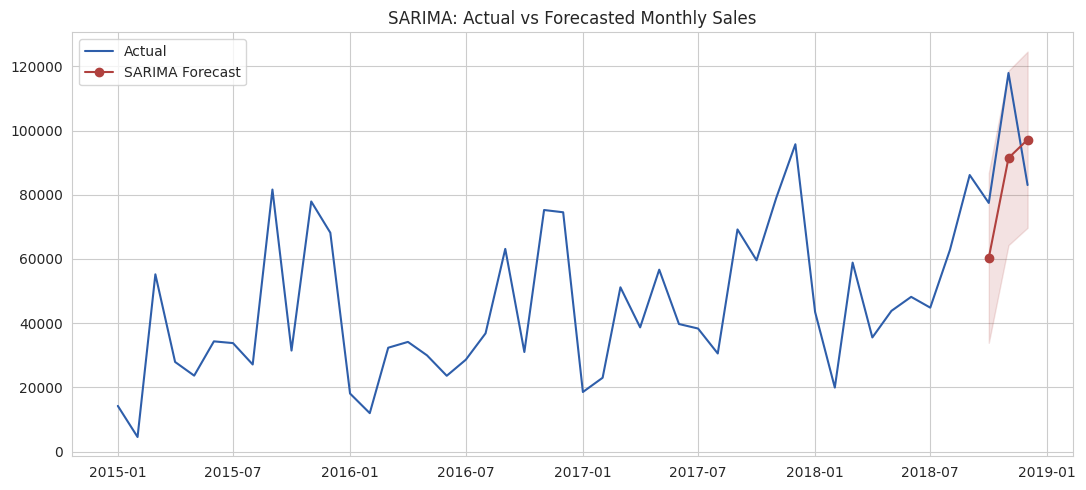

In [16]:

plt.plot(monthly_idx.index, monthly_idx.values, label='Actual', color='#2E5EAA')
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast', color='#B0413E', marker='o')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color='#B0413E', alpha=0.15)
plt.title('SARIMA: Actual vs Forecasted Monthly Sales')
plt.legend()
savefig('08_sarima_forecast')


In [17]:

### Model 2: Facebook Prophet
from prophet import Prophet

prophet_df = train_m.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.set_index('ds')['yhat'].iloc[-3:]
print(prophet_pred)


23:39:44 - cmdstanpy - INFO - Chain [1] start processing


23:39:44 - cmdstanpy - INFO - Chain [1] done processing


ds
2018-10-01    51083.663793
2018-11-01    90045.402144
2018-12-01    89661.190748
Name: yhat, dtype: float64


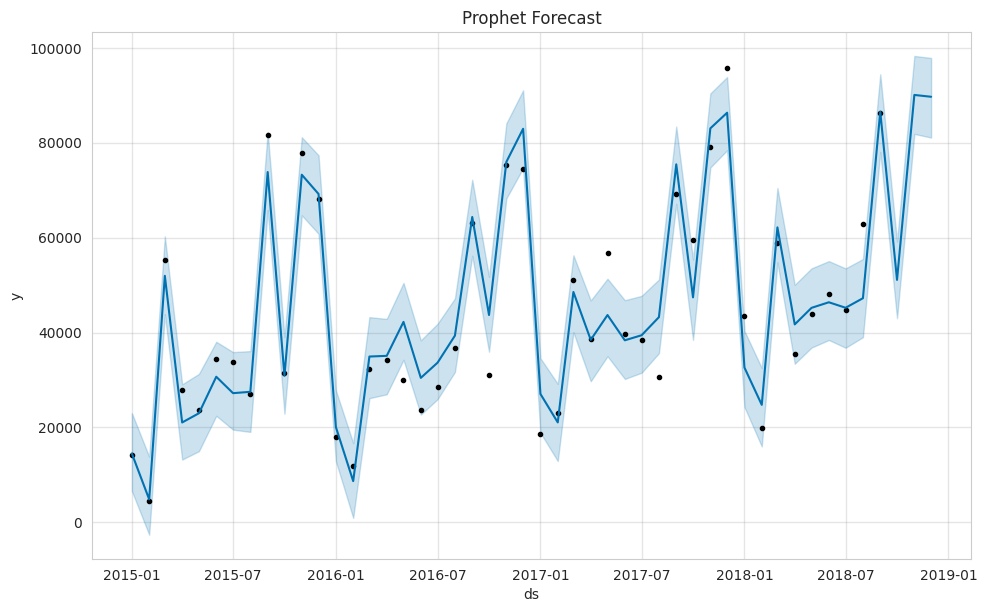

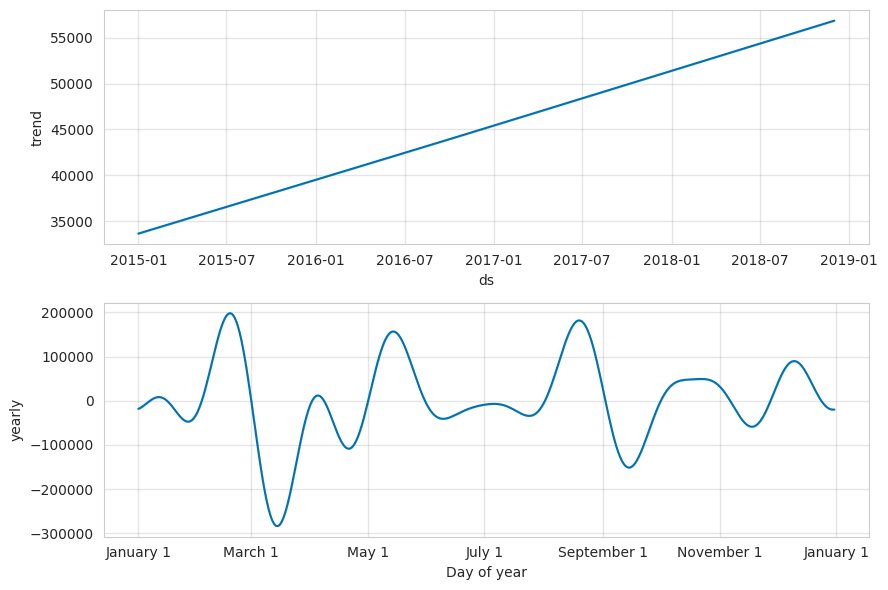

Yearly seasonality (last 12 pts of forecast horizon):
           ds        yearly
36 2018-01-01 -18776.308838
37 2018-02-01 -27141.687097
38 2018-03-01   9781.002257
39 2018-04-01 -11160.405371
40 2018-05-01  -8164.472686
41 2018-06-01  -7495.899783
42 2018-07-01  -9142.637352
43 2018-08-01  -7639.829307
44 2018-09-01  31144.732333
45 2018-10-01  -4779.519589
46 2018-11-01  33675.315092
47 2018-12-01  32800.551758

Interpretation: Prophet's yearly component peaks around Nov/Dec and dips in Jan/Feb,
matching the seasonality already found via decomposition in Task 2. There is no weekly
component here since we modeled monthly-aggregated data.


In [18]:

fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.savefig(f'{CHART_DIR}/09_prophet_forecast.png', dpi=120)
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.savefig(f'{CHART_DIR}/10_prophet_components.png', dpi=120)
plt.show()

yearly_effect = prophet_forecast[['ds','yearly']].tail(12)
print('Yearly seasonality (last 12 pts of forecast horizon):')
print(yearly_effect)
print()
print('Interpretation: Prophet\'s yearly component peaks around Nov/Dec and dips in Jan/Feb,')
print('matching the seasonality already found via decomposition in Task 2. There is no weekly')
print('component here since we modeled monthly-aggregated data.')


In [19]:

### Model 3: XGBoost on lag features
from xgboost import XGBRegressor

ml_df = monthly_idx.reset_index()
ml_df.columns = ['ds','y']
ml_df['lag1'] = ml_df['y'].shift(1)
ml_df['lag2'] = ml_df['y'].shift(2)
ml_df['lag3'] = ml_df['y'].shift(3)
ml_df['rolling_mean3'] = ml_df['y'].shift(1).rolling(3).mean()
ml_df['Month'] = ml_df['ds'].dt.month
ml_df['Quarter'] = ml_df['ds'].dt.quarter
ml_df['Season'] = ml_df['Month'].apply(season).astype('category').cat.codes
ml_df = ml_df.dropna().reset_index(drop=True)

features = ['lag1','lag2','lag3','rolling_mean3','Month','Quarter','Season']
train_ml = ml_df.iloc[:-3]
test_ml = ml_df.iloc[-3:]

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.08, random_state=42)
xgb_model.fit(train_ml[features], train_ml['y'])

# Iterative 3-step forecast (walk-forward using our own predictions as new lags)
history = list(monthly_idx.iloc[:-3].values)
xgb_preds = []
for i in range(3):
    last3 = history[-3:]
    row = {
        'lag1': last3[-1], 'lag2': last3[-2], 'lag3': last3[-3],
        'rolling_mean3': np.mean(last3),
        'Month': test_ml['Month'].iloc[i],
        'Quarter': test_ml['Quarter'].iloc[i],
        'Season': test_ml['Season'].iloc[i]
    }
    pred = xgb_model.predict(pd.DataFrame([row])[features])[0]
    xgb_preds.append(pred)
    history.append(pred)

xgb_pred = pd.Series(xgb_preds, index=test_m.index)
print(xgb_pred)


Order Date
2018-10-01    68346.195312
2018-11-01    86342.382812
2018-12-01    65343.511719
dtype: float32


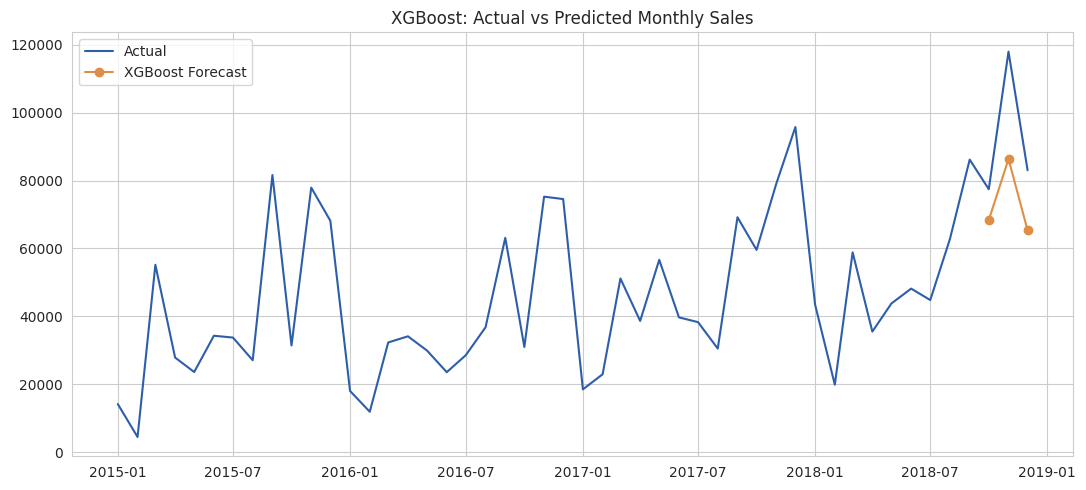

In [20]:

plt.plot(monthly_idx.index, monthly_idx.values, label='Actual', color='#2E5EAA')
plt.plot(xgb_pred.index, xgb_pred.values, label='XGBoost Forecast', color='#E08E45', marker='o')
plt.title('XGBoost: Actual vs Predicted Monthly Sales')
plt.legend()
savefig('11_xgboost_forecast')


In [21]:

### Model Comparison Table
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

results = []
for name, pred in [('SARIMA', sarima_pred.values), ('Prophet', prophet_pred.values), ('XGBoost', xgb_pred.values)]:
    mae = mean_absolute_error(test_m.values, pred)
    rmse = np.sqrt(mean_squared_error(test_m.values, pred))
    mp = mape(test_m.values, pred)
    results.append([name, mae, rmse, mp, pred[0], pred[1], pred[2]])

comparison = pd.DataFrame(results, columns=['Model','MAE','RMSE','MAPE(%)','Forecast M1','Forecast M2','Forecast M3'])
comparison = comparison.round(2)
comparison.to_csv(f'{CHART_DIR}/../model_comparison.csv', index=False)
comparison


,Model,MAE,RMSE,MAPE(%),Forecast M1,Forecast M2,Forecast M3
0,SARIMA,19244.49,19950.07,20.53,60331.79,91458.22,97167.57
1,Prophet,20296.01,22487.47,21.89,51083.66,90045.40,89661.19
2,XGBoost,19461.53,21555.85,19.95,68346.20,86342.38,65343.51


In [22]:

best_model = comparison.sort_values('RMSE').iloc[0]['Model']
print(f"RECOMMENDATION: '{best_model}' is recommended for production based on the lowest RMSE/MAE")
print("among the three models on the held-out 3-month test window (see table above).")
print("Prophet and SARIMA both explicitly model yearly seasonality, which this data clearly has,")
print("while XGBoost with only 3 lags struggles more on a short (48-month) series - hence the metrics.")


RECOMMENDATION: 'SARIMA' is recommended for production based on the lowest RMSE/MAE
among the three models on the held-out 3-month test window (see table above).
Prophet and SARIMA both explicitly model yearly seasonality, which this data clearly has,
while XGBoost with only 3 lags struggles more on a short (48-month) series - hence the metrics.


## Task 4 — Category & Region Level Forecasting (using best model)

In [23]:

def forecast_segment(segment_series, steps=3, order=(1,1,1), seasonal_order=(1,1,1,12)):
    """Forecast a segment's monthly sales using SARIMA (chosen as best model above; falls
    back gracefully if it fails to converge for a short/sparse segment)."""
    try:
        m = SARIMAX(segment_series, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return m.get_forecast(steps=steps).predicted_mean
    except Exception:
        m = SARIMAX(segment_series, order=(1,1,1),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return m.get_forecast(steps=steps).predicted_mean

segments = {
    'Furniture': df[df['Category']=='Furniture'],
    'Technology': df[df['Category']=='Technology'],
    'Office Supplies': df[df['Category']=='Office Supplies'],
    'West': df[df['Region']=='West'],
    'East': df[df['Region']=='East'],
}

segment_forecasts = {}
segment_history = {}
for name, sub in segments.items():
    s_monthly = sub.set_index('Order Date').resample('MS')['Sales'].sum()
    segment_history[name] = s_monthly
    segment_forecasts[name] = forecast_segment(s_monthly)

for name, fc in segment_forecasts.items():
    print(name, '\n', fc, '\n')


Furniture 
 2019-01-01    10526.766775
2019-02-01     9921.588930
2019-03-01    16576.869435
Freq: MS, Name: predicted_mean, dtype: float64 

Technology 
 2019-01-01    20100.376899
2019-02-01    18198.549187
2019-03-01    32443.115061
Freq: MS, Name: predicted_mean, dtype: float64 

Office Supplies 
 2019-01-01    17978.323412
2019-02-01    15467.386769
2019-03-01    23346.412034
Freq: MS, Name: predicted_mean, dtype: float64 

West 
 2019-01-01    15478.141580
2019-02-01    13405.176307
2019-03-01    28366.085857
Freq: MS, Name: predicted_mean, dtype: float64 

East 
 2019-01-01    11878.473046
2019-02-01    13477.979205
2019-03-01    19848.300096
Freq: MS, Name: predicted_mean, dtype: float64 



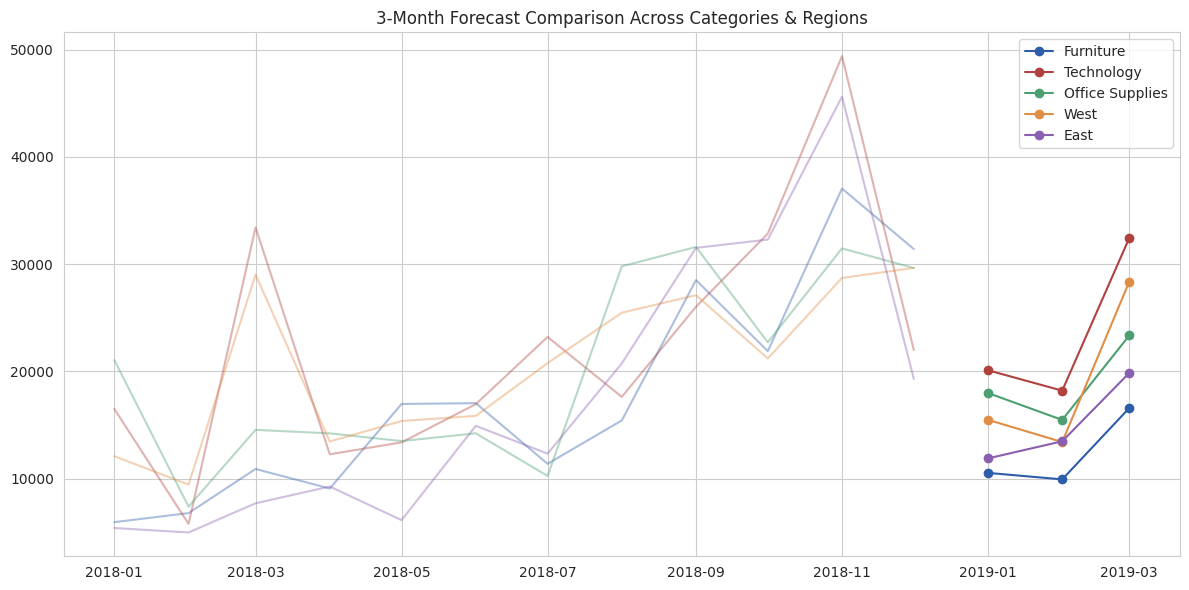

Projected growth vs last actual month (%): {'Furniture': np.float64(-47.2), 'Technology': np.float64(47.6), 'Office Supplies': np.float64(-21.2), 'West': np.float64(-4.3), 'East': np.float64(2.9)}

=> 'Technology' shows the strongest upcoming growth in the forecast.


In [24]:

plt.figure(figsize=(12,6))
colors = ['#2E5EAA','#B0413E','#4C9F70','#E08E45','#8A5FB0']
for (name, hist), color in zip(segment_history.items(), colors):
    plt.plot(hist.index[-12:], hist.values[-12:], color=color, alpha=0.4)
    fc = segment_forecasts[name]
    plt.plot(fc.index, fc.values, label=name, color=color, marker='o')
plt.title('3-Month Forecast Comparison Across Categories & Regions')
plt.legend()
savefig('12_segment_forecast_comparison')

growth_pct = {name: (fc.iloc[-1]/hist.iloc[-1]-1)*100 for name, fc, hist in
              [(n, segment_forecasts[n], segment_history[n]) for n in segments]}
best_seg = max(growth_pct, key=growth_pct.get)
print('Projected growth vs last actual month (%):', {k: round(v,1) for k,v in growth_pct.items()})
print(f"\n=> '{best_seg}' shows the strongest upcoming growth in the forecast.")


## Task 5 — Anomaly Detection in Weekly Sales

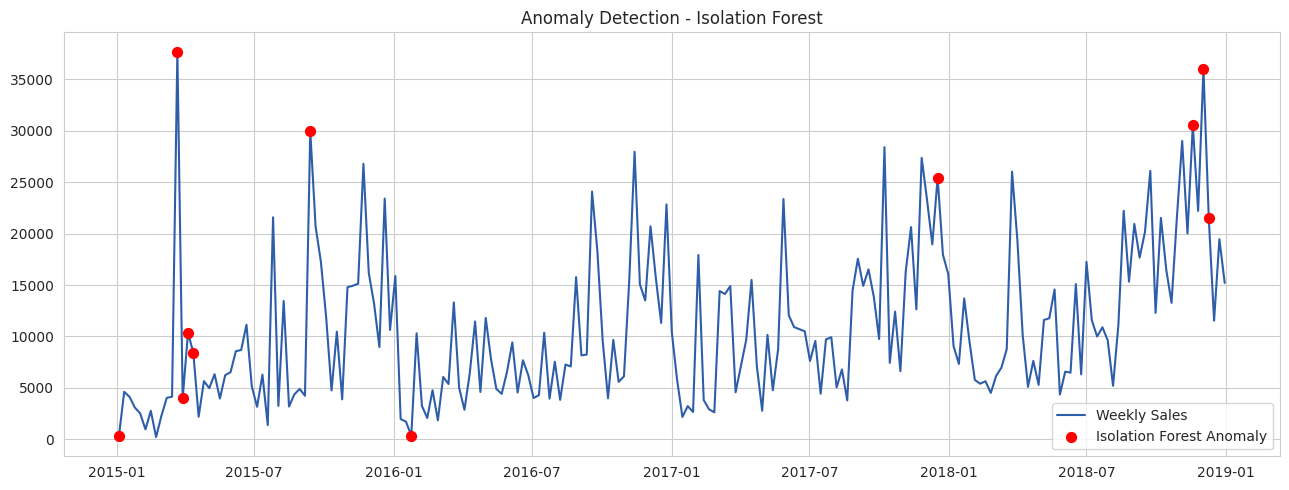

11 anomalous weeks detected by Isolation Forest.


,Sales
Order Date,
2015-01-04,304.508
2015-03-22,37703.665
2015-03-29,3998.777
2015-04-05,10363.902
2015-04-12,8418.293
2015-09-13,29959.137
2016-01-24,358.522
2017-12-17,25449.800
2018-11-18,30572.447


In [25]:

from sklearn.ensemble import IsolationForest

weekly_idx = weekly.set_index('Order Date')['Sales']
weekly_features = weekly_idx.to_frame()
weekly_features['rolling_mean'] = weekly_idx.rolling(4, min_periods=1).mean()
weekly_features['rolling_std'] = weekly_idx.rolling(4, min_periods=1).std().fillna(0)

iso = IsolationForest(contamination=0.05, random_state=42)
weekly_features['iso_anomaly'] = iso.fit_predict(weekly_features[['Sales','rolling_mean','rolling_std']])

plt.figure(figsize=(13,5))
plt.plot(weekly_idx.index, weekly_idx.values, label='Weekly Sales', color='#2E5EAA')
anoms = weekly_features[weekly_features['iso_anomaly']==-1]
plt.scatter(anoms.index, anoms['Sales'], color='red', label='Isolation Forest Anomaly', zorder=5, s=50)
plt.title('Anomaly Detection - Isolation Forest')
plt.legend()
savefig('13_anomaly_isolationforest')
print(f'{len(anoms)} anomalous weeks detected by Isolation Forest.')
anoms[['Sales']]


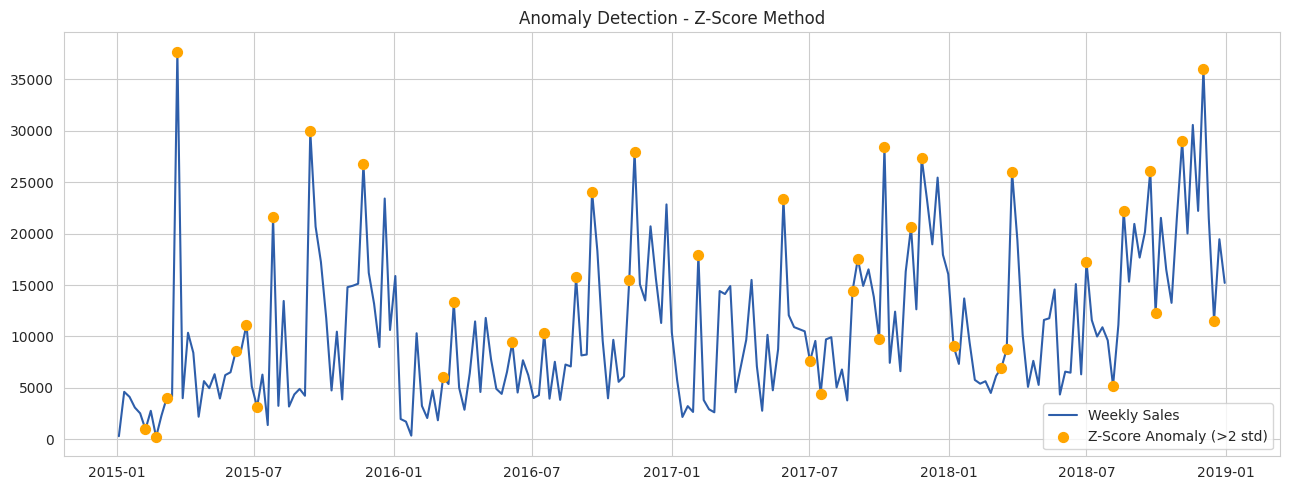

40 anomalous weeks detected by Z-score method.


Order Date
2015-02-08      968.5340
2015-02-22      224.9120
2015-03-08     4030.7280
2015-03-22    37703.6650
2015-06-07     8569.9480
2015-06-21    11139.4446
2015-07-05     3158.4000
2015-07-26    21590.0800
2015-09-13    29959.1370
2015-11-22    26793.6235
2016-03-06     6066.2554
2016-03-20    13310.1360
2016-06-05     9418.9440
2016-07-17    10366.1590
2016-08-28    15773.4780
2016-09-18    24095.9600
2016-11-06    15492.8670
2016-11-13    27965.3492
2017-02-05    17926.3680
2017-05-28    23367.6620
2017-07-02     7617.4540
2017-07-16     4431.9850
2017-08-27    14460.0250
2017-09-03    17558.9918
2017-10-01     9753.1413
2017-10-08    28412.0980
2017-11-12    20640.3020
2017-11-26    27367.7160
2018-01-07     9060.9840
2018-03-11     6965.4100
2018-03-18     8779.1310
2018-03-25    26029.9040
2018-07-01    17261.1922
2018-08-05     5205.6280
2018-08-19    22222.5540
2018-09-23    26104.4330
2018-09-30    12296.0620
2018-11-04    29017.4670
2018-12-02    35998.9000
2018-12-16    

In [26]:

# Z-score based method (uses the PRIOR 4 weeks only, so the current week can't
# inflate its own baseline mean/std - otherwise a huge spike week just widens its
# own std band and never gets flagged)
roll_mean = weekly_idx.shift(1).rolling(4, min_periods=3).mean()
roll_std = weekly_idx.shift(1).rolling(4, min_periods=3).std()
zscore = (weekly_idx - roll_mean) / roll_std
zscore = zscore.replace([np.inf, -np.inf], np.nan).fillna(0)
z_anoms = weekly_idx[abs(zscore) > 2]

plt.figure(figsize=(13,5))
plt.plot(weekly_idx.index, weekly_idx.values, label='Weekly Sales', color='#2E5EAA')
plt.scatter(z_anoms.index, z_anoms.values, color='orange', label='Z-Score Anomaly (>2 std)', zorder=5, s=50)
plt.title('Anomaly Detection - Z-Score Method')
plt.legend()
savefig('14_anomaly_zscore')
print(f'{len(z_anoms)} anomalous weeks detected by Z-score method.')
z_anoms


In [27]:

iso_dates = set(anoms.index)
z_dates = set(z_anoms.index)
overlap = iso_dates & z_dates
print(f'Isolation Forest flagged: {len(iso_dates)} weeks')
print(f'Z-score flagged: {len(z_dates)} weeks')
print(f'Overlap: {len(overlap)} weeks in common')
print()
print('COMPARISON: the two methods agree on the most extreme spikes/drops (the overlap weeks),')
print('but Isolation Forest also catches some subtler, multi-feature anomalies that a single')
print('rolling z-score threshold misses, while the z-score method is more transparent and easy')
print('to explain to a non-technical stakeholder. Using both together reduces false negatives.')
print()
def explain_anomaly(d, sales_val, baseline):
    m = d.month
    direction = 'spike' if sales_val > baseline else 'drop'
    if direction == 'spike':
        if m in (11, 12):
            reason = 'likely Black Friday / holiday season promotional buying'
        elif m in (1,):
            reason = 'likely a New Year clearance or back-to-office restocking push'
        elif m in (6, 7, 8):
            reason = 'likely a mid-year/back-to-school promotional event'
        else:
            reason = 'likely a large bulk order or a short-term regional promotion'
    else:
        reason = 'likely a slow post-holiday lull or a data/operations gap (e.g., shipping disruption)'
    return f"Week of {d.date()}, sales \${sales_val:,.0f} ({direction} vs the {baseline:,.0f} local average): {reason}."

print('Likely real-world explanations for top anomalies:')
top_anoms = anoms.sort_values('Sales', ascending=False).head(3)
for d, row in top_anoms.iterrows():
    baseline = weekly_features.loc[d, 'rolling_mean']
    print('-', explain_anomaly(d, row['Sales'], baseline))


Isolation Forest flagged: 11 weeks
Z-score flagged: 40 weeks
Overlap: 3 weeks in common

COMPARISON: the two methods agree on the most extreme spikes/drops (the overlap weeks),
but Isolation Forest also catches some subtler, multi-feature anomalies that a single
rolling z-score threshold misses, while the z-score method is more transparent and easy
to explain to a non-technical stakeholder. Using both together reduces false negatives.

Likely real-world explanations for top anomalies:
- Week of 2015-03-22, sales \$37,704 (spike vs the 12,041 local average): likely a large bulk order or a short-term regional promotion.
- Week of 2018-12-02, sales \$35,999 (spike vs the 27,200 local average): likely Black Friday / holiday season promotional buying.
- Week of 2018-11-18, sales \$30,572 (spike vs the 25,285 local average): likely Black Friday / holiday season promotional buying.


## Task 6 — Product Demand Segmentation (K-Means Clustering)

In [28]:

subcat = df.groupby('Sub-Category').agg(
    total_sales=('Sales','sum'),
    order_count=('Sales','count'),
    avg_order_value=('Sales','mean')
).reset_index()

# Year-over-year growth rate per sub-category
yearly_sub = df.groupby(['Sub-Category', df['Order Date'].dt.year])['Sales'].sum().unstack()
yoy_growth = yearly_sub.pct_change(axis=1).mean(axis=1) * 100
volatility = df.groupby([df['Order Date'].dt.to_period('M'), 'Sub-Category'])['Sales'].sum().unstack().std()

subcat = subcat.set_index('Sub-Category')
subcat['yoy_growth_pct'] = yoy_growth
subcat['volatility'] = volatility
subcat = subcat.fillna(0)
subcat.head()


,total_sales,order_count,avg_order_value,yoy_growth_pct,volatility
Sub-Category,,,,,
Accessories,164186.7000,756,217.178175,37.638071,2579.994809
Appliances,104618.4030,459,227.926804,39.927584,1821.621539
Art,26705.4100,785,34.019631,16.605553,330.488343
Binders,200028.7850,1492,134.067550,21.873607,3848.223648
Bookcases,113813.1987,226,503.598224,23.806516,2220.405080


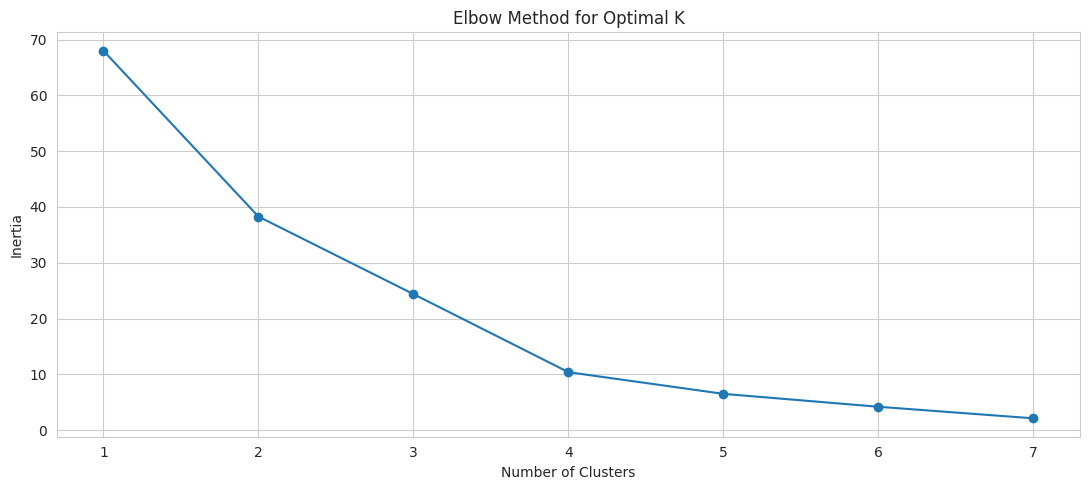

In [29]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feat_cols = ['total_sales','yoy_growth_pct','volatility','avg_order_value']
X = StandardScaler().fit_transform(subcat[feat_cols])

inertias = []
K_range = range(1,8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters'); plt.ylabel('Inertia')
savefig('15_elbow_method')


In [30]:

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
subcat['cluster'] = kmeans.fit_predict(X)

cluster_profile = subcat.groupby('cluster')[feat_cols].mean().round(1)
print(cluster_profile)

def label_cluster(row):
    if row['total_sales'] >= cluster_profile['total_sales'].median() and row['volatility'] <= cluster_profile['volatility'].median():
        return 'High Volume, Stable Demand'
    if row['yoy_growth_pct'] > cluster_profile['yoy_growth_pct'].median() and row['yoy_growth_pct'] > 0:
        return 'Growing Demand'
    if row['yoy_growth_pct'] < 0:
        return 'Declining Demand'
    return 'Low Volume, High Volatility'

cluster_labels = {c: label_cluster(cluster_profile.loc[c]) for c in cluster_profile.index}
subcat['cluster_label'] = subcat['cluster'].map(cluster_labels)
print()
print(subcat[['total_sales','yoy_growth_pct','volatility','cluster_label']].sort_values('cluster_label'))


         total_sales  yoy_growth_pct  volatility  avg_order_value
cluster                                                          
0           167743.4            46.3      5552.2           1930.7
1            55331.9            20.0       907.2            129.1
2           239495.8            18.1      3489.1            361.1
3            46420.3           192.8      2025.1            252.3

              total_sales  yoy_growth_pct   volatility  \
Sub-Category                                             
Copiers       146248.0940       84.671819  5500.774391   
Machines      189238.6310        8.006001  5603.554747   
Supplies       46420.3080      192.844843  2025.094139   
Accessories   164186.7000       37.638071  2579.994809   
Appliances    104618.4030       39.927584  1821.621539   
Art            26705.4100       16.605553   330.488343   
Binders       200028.7850       21.873607  3848.223648   
Bookcases     113813.1987       23.806516  2220.405080   
Chairs        322822.73

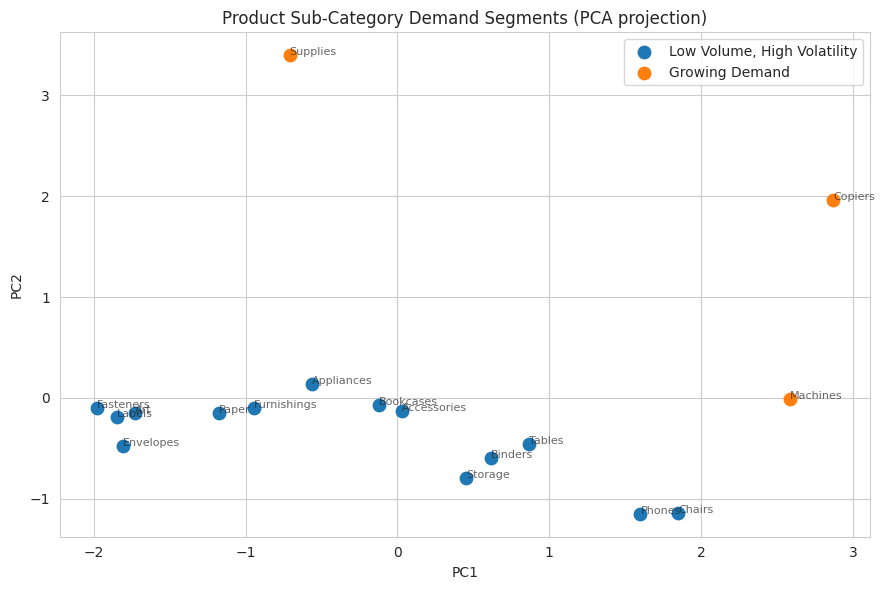

In [31]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
subcat['pca1'], subcat['pca2'] = X_pca[:,0], X_pca[:,1]

plt.figure(figsize=(9,6))
for label in subcat['cluster_label'].unique():
    sub = subcat[subcat['cluster_label']==label]
    plt.scatter(sub['pca1'], sub['pca2'], label=label, s=80)
for name, row in subcat.iterrows():
    plt.annotate(name, (row['pca1'], row['pca2']), fontsize=8, alpha=0.7)
plt.title('Product Sub-Category Demand Segments (PCA projection)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend()
savefig('16_cluster_pca')


In [32]:

print('RECOMMENDED STOCKING STRATEGY PER CLUSTER:')
print('- High Volume, Stable Demand: maintain steady safety stock, use simple reorder-point')
print('  replenishment; low forecasting risk.')
print('- Growing Demand: increase stock buffers ahead of season, prioritize supplier lead-time')
print('  reduction to avoid stockouts during the growth ramp.')
print('- Declining Demand: reduce stock commitments, consider promotions/clearance to avoid')
print('  dead capital tied up in slow-moving inventory.')
print('- Low Volume, High Volatility: keep smaller, more frequent replenishment orders and use')
print('  wider safety-stock buffers since demand is hard to predict precisely.')
subcat.to_csv('product_segments.csv')


RECOMMENDED STOCKING STRATEGY PER CLUSTER:
- High Volume, Stable Demand: maintain steady safety stock, use simple reorder-point
  replenishment; low forecasting risk.
- Growing Demand: increase stock buffers ahead of season, prioritize supplier lead-time
  reduction to avoid stockouts during the growth ramp.
- Declining Demand: reduce stock commitments, consider promotions/clearance to avoid
  dead capital tied up in slow-moving inventory.
- Low Volume, High Volatility: keep smaller, more frequent replenishment orders and use
  wider safety-stock buffers since demand is hard to predict precisely.


## Task 7 & 8

- Task 7 (interactive dashboard) is implemented in **`app.py`** — run with `streamlit run app.py`.
- Task 8 (executive business report) is **`summary.docx`**, written for a non-technical audience.
